In [1]:
!pip install sentence-transformers
!pip install faiss-cpu
!pip install wordcloud
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 29.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

from wordcloud import WordCloud
import faiss

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Dataset-SA.csv to Dataset-SA.csv


In [7]:
df = pd.read_csv("Dataset-SA.csv")
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [8]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (205052, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [9]:
df = df.dropna()

df["Review"] = df["Review"].astype(str)

df = df.head(20000)

df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


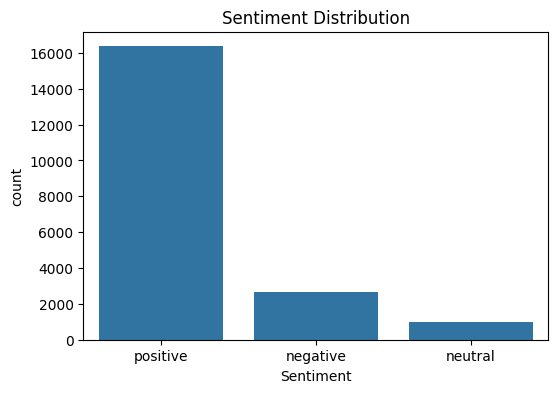

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sentiment", data=df)

plt.title("Sentiment Distribution")

plt.show()

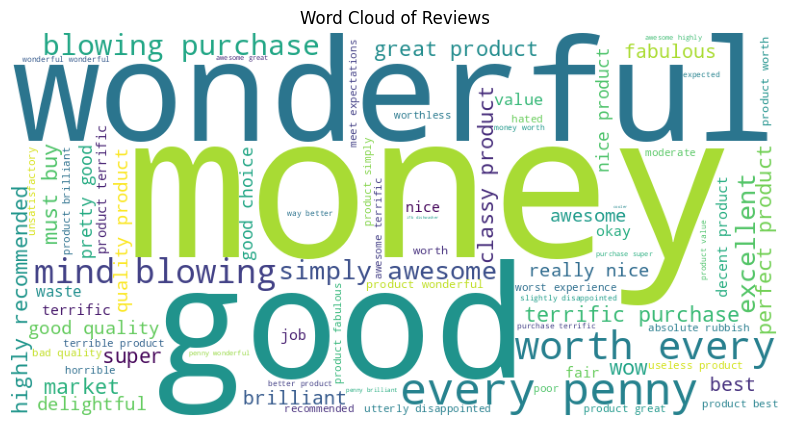

In [11]:
text = " ".join(df["Review"].tolist())

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud of Reviews")

plt.show()

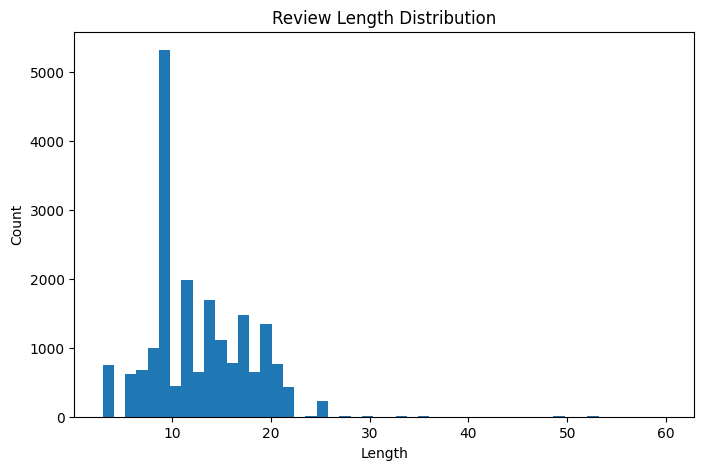

In [12]:
df["review_length"] = df["Review"].apply(len)

plt.figure(figsize=(8,5))

plt.hist(df["review_length"], bins=50)

plt.title("Review Length Distribution")

plt.xlabel("Length")

plt.ylabel("Count")

plt.show()

In [13]:
model = SentenceTransformer("all-MiniLM-L6-v2")

reviews = df["Review"].tolist()

embeddings = model.encode(reviews)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(embeddings))

In [15]:
def semantic_search(query):

    query_embedding = model.encode([query])

    distances, indices = index.search(np.array(query_embedding), k=5)

    results = df.iloc[indices[0]]

    return results[["product_name","Review","Sentiment"]]

In [16]:
semantic_search("good battery life phone")

,product_name,Review,Sentiment
2683,boAt Rockerz 510 Super Extra Bass Bluetooth He...,very good at this price and battery bakcup awsm,positive
6854,"Canon EOS 3000D DSLR Camera 1 Camera Body, 18 ...",good camera for this price range.,negative
2418,boAt Rockerz 510 Super Extra Bass Bluetooth He...,"highly recommended.worth buying,high bass,long...",positive
2562,boAt Rockerz 510 Super Extra Bass Bluetooth He...,"great headphone, got it for rs 1599",positive
18912,Seagate One Touch with Password Protection for...,excellent and must buy,positive


In [17]:
def rag_system(query):

    results = semantic_search(query)

    context = " ".join(results["Review"].tolist())

    answer = "Based on customer reviews: " + context[:400]

    return answer

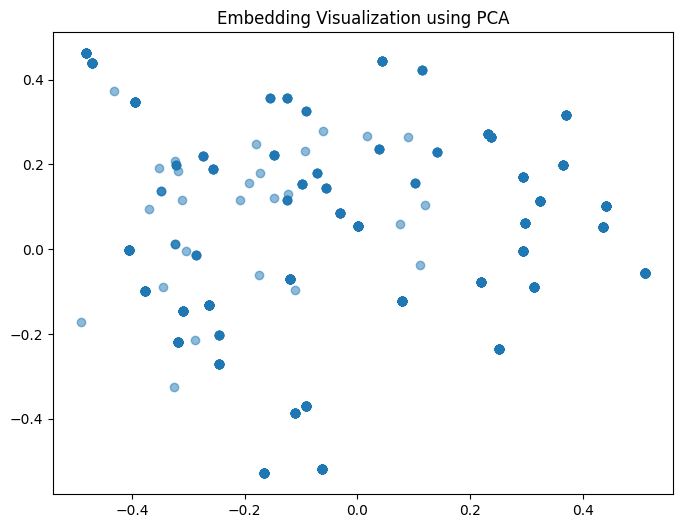

In [18]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings[:1000])

plt.figure(figsize=(8,6))

plt.scatter(reduced[:,0], reduced[:,1], alpha=0.5)

plt.title("Embedding Visualization using PCA")

plt.show()

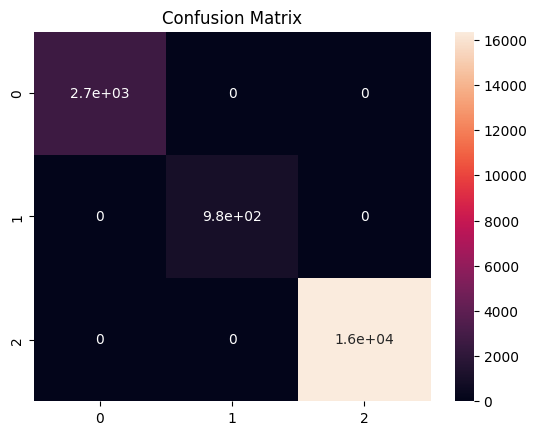

In [19]:
cm = confusion_matrix(df["Sentiment"], df["Sentiment"])

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")

plt.show()

Business Insights

This project demonstrates how text embeddings can be used to build a
semantic search system for product reviews.

Traditional keyword search fails when users use different words to
describe the same intent. Using sentence transformer embeddings helps
capture the semantic meaning of the reviews.

Using FAISS vector indexing allows fast similarity search across
thousands of product reviews.

This system can help e-commerce companies analyze customer feedback,
identify product issues, and improve recommendation systems.
